# MSTC-IDS — Phase 2: Component × Modality Ablation Study (21 combinations)

Combines the two ablation axes explored so far: **7 architectural components** ×
**3 modalities** (cyber-only, physical-only, cyber-physical fused) = **21 trained
models**, all on identical data splits/seed/epochs.

| # | Component variant | What's removed |
|---|---|---|
| 1 | **Full model** | nothing (baseline) |
| 2 | **w/o Time2Vec** | sinusoidal irregular-time encoding → plain linear projection of raw Δt |
| 3 | **w/o Cross-Attention** | gated cyber↔physical cross-attention fusion → naive concatenation of independently-encoded CLS tokens |
| 4 | **w/o Contrastive Loss** | InfoNCE cyber-physical alignment term (architecture unchanged, `contrastive_weight=0`) |
| 5 | **w/o Multi-Scale Pyramid** | multi-scale temporal convolution features → CLS tokens only |
| 6 | **w/o Causal Masking** | strict causal self-attention → full bidirectional self-attention |
| 7 | **w/o Freshness Embedding** | packet-freshness signal (replay-detection cue) removed from the cyber stream |

Each of these 7 is trained under `modality="cyber"`, `"physical"`, and `"both"`.

**Expected redundancy (not a bug):** two of the seven components only exist when
both modalities are fused — cross-attention has nothing to fuse with a single
branch, and the contrastive loss has no second stream to align against (it's forced
to `contrastive_weight=0` for single-modality runs regardless of the component
flag, same convention as the earlier modality ablation). Freshness is only ever
wired into the cyber branch, never the physical one. Concretely:
- `no_cross_attention` and `no_contrastive` under `cyber` or `physical` modality are
  **architecturally identical** to `full` under that same modality.
- `no_freshness` under `physical` modality is **architecturally identical** to
  `full` under `physical` modality.

These rows are still trained and reported independently (as requested) rather than
skipped/copied, so any difference you see between them and `full` in those cases is
purely training-noise (different random batch order/dropout draws), not a real
architectural effect — worth keeping in mind when reading the results.

This notebook assumes the same folder layout as Phase 1/2:

```
./segment_data/    (benign_cyber.csv, benign_physical.csv, ... x5 attacks)
./mstc_ids_model.py   (must include the modality + component ablation flags)
./losses.py
./uncertainty.py
```

## 1. Environment Setup

In [1]:
import os
import sys
import json
import random
import warnings

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.makedirs("figures", exist_ok=True)
random.seed(SEED)

DATA_DIR = "segment_data"
WINDOW_SIZE = 20
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 5

LABEL_MAP = {"benign": 0, "dos": 1, "replay": 2, "eviltwin": 3, "fdi": 4}
CLASS_NAMES = ["Benign", "DoS", "Replay", "EvilTwin", "FDI"]
ATTACKS = ["benign", "dos", "replay", "eviltwin", "fdi"]

print("Data directory:", DATA_DIR)

Data directory: segment_data


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
import tf_keras as keras   # import tf_keras directly, not `from tensorflow import keras`
                            # (see Phase 1 notebook for why)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("tf_keras  :", keras.__version__)

I0000 00:00:1787040741.975015   11201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1787040745.599867   11201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
tf_keras  : 2.21.0


## 3. Load MSTC-IDS Modules

In [3]:
for _p in (os.getcwd(), os.path.join(os.getcwd(), "code")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from notebook_helpers import get_or_train, get_or_train_baseline

from mstc_ids_model import MSTCIDS
from losses import MSTCTrainer

print("Loaded MSTCIDS (with `modality` support) and MSTCTrainer")

Loaded MSTCIDS (with `modality` support) and MSTCTrainer


## 4. Load, Align, Window, Split & Scale Data

Identical pipeline to Phase 1 (same bug fixes: explicit `_cyber`/`_physical`
suffixing before merge, synthetic timestamp for the FDI physical segment, etc.).
Condensed into fewer cells here since it's unchanged from Phase 1 — see that
notebook for the detailed walkthrough of each step.

In [4]:
def fix_and_load_raw(path, attack, domain):
    df = pd.read_csv(path)
    df.columns = [str(c).lower().strip() for c in df.columns]

    timestamp_candidates = ["timestamp", "timestamp_c", "timestamp_p", "frame.time_epoch", "time"]
    timestamp_col = next((c for c in timestamp_candidates if c in df.columns), None)

    if timestamp_col is not None:
        if timestamp_col != "timestamp":
            df = df.rename(columns={timestamp_col: "timestamp"})
    else:
        if domain == "physical":
            df["timestamp"] = np.arange(len(df)) * 0.01
        else:
            raise ValueError(f"No timestamp column found in cyber file: {path}")

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    for col in ("class", "label"):
        if col in df.columns:
            df = df.drop(columns=[col])

    return df


def remove_constant_features(df, protected=("timestamp",)):
    drop_cols = [c for c in df.columns if c not in protected and df[c].nunique(dropna=False) <= 1]
    return df.drop(columns=drop_cols, errors="ignore")


def synchronize_streams(cyber, physical):
    cyber = cyber.sort_values("timestamp").copy()
    physical = physical.sort_values("timestamp").copy()
    cyber["timestamp"] = pd.to_numeric(cyber["timestamp"], errors="coerce")
    physical["timestamp"] = pd.to_numeric(physical["timestamp"], errors="coerce")
    cyber = cyber.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})
    physical = physical.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})

    cyber = cyber.rename(columns={c: f"{c}_cyber" for c in cyber.columns if c != "timestamp"})
    physical = physical.rename(columns={c: f"{c}_physical" for c in physical.columns if c != "timestamp"})

    return pd.merge_asof(cyber, physical, on="timestamp", direction="nearest")


def load_attack_segment(attack):
    cyber = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_cyber.csv"), attack, "cyber"))
    physical = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_physical.csv"), attack, "physical"))
    fused = synchronize_streams(cyber, physical)
    fused["attack"] = attack
    fused["label"] = LABEL_MAP[attack]
    return fused


def align_feature_dimensions(segments):
    cyber_features, physical_features = set(), set()
    for df in segments:
        for c in df.columns:
            if c.endswith("_cyber"):
                cyber_features.add(c)
            elif c.endswith("_physical"):
                physical_features.add(c)
    cyber_features = sorted(cyber_features)
    physical_features = sorted(physical_features)

    aligned = []
    for df in segments:
        df = df.copy()
        for c in cyber_features + physical_features:
            if c not in df.columns:
                df[c] = 0.0
        aligned.append(df[["timestamp"] + cyber_features + physical_features + ["attack", "label"]])
    return aligned, cyber_features, physical_features


def create_windows(df, cyber_features, physical_features, window_size=WINDOW_SIZE):
    Xc_all = df[cyber_features].values.astype(np.float32)
    Xp_all = df[physical_features].values.astype(np.float32)
    ts = df["timestamp"].values.astype(np.float64)
    labels = df["label"].values.astype(np.int64)

    Xc, Xp, Xt, Xf, y = [], [], [], [], []
    for i in range(len(df) - window_size):
        Xc.append(Xc_all[i:i + window_size])
        Xp.append(Xp_all[i:i + window_size])
        delta = np.insert(np.diff(ts[i:i + window_size]), 0, 0).reshape(window_size, 1)
        Xt.append(delta)
        Xf.append(delta)
        y.append(labels[i + window_size - 1])

    return (
        np.asarray(Xc, dtype=np.float32), np.asarray(Xp, dtype=np.float32),
        np.asarray(Xt, dtype=np.float32), np.asarray(Xf, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
    )


def temporal_split(windows, train_frac=0.70, val_frac=0.15):
    n = len(windows[4])
    train_end, val_end = int(n * train_frac), int(n * (train_frac + val_frac))
    train = tuple(x[:train_end] for x in windows)
    val = tuple(x[train_end:val_end] for x in windows)
    test = tuple(x[val_end:] for x in windows)
    return train, val, test


def combine_splits(split_list):
    return tuple(np.concatenate([s[i] for s in split_list], axis=0) for i in range(5))


segments = [load_attack_segment(a) for a in ATTACKS]
segments, cyber_features, physical_features = align_feature_dimensions(segments)

train_parts, val_parts, test_parts = [], [], []
for seg in segments:
    w = create_windows(seg, cyber_features, physical_features)
    tr, va, te = temporal_split(w)
    train_parts.append(tr); val_parts.append(va); test_parts.append(te)

train = combine_splits(train_parts)
val = combine_splits(val_parts)
test = combine_splits(test_parts)

scaler_c, scaler_p = StandardScaler(), StandardScaler()
Xc_train, Xp_train, Xt_train, Xf_train, y_train = train
Xc_val, Xp_val, Xt_val, Xf_val, y_val = val
Xc_test, Xp_test, Xt_test, Xf_test, y_test = test

shape = Xc_train.shape
Xc_train = scaler_c.fit_transform(Xc_train.reshape(-1, shape[-1])).reshape(shape)
Xc_val = scaler_c.transform(Xc_val.reshape(-1, Xc_val.shape[-1])).reshape(Xc_val.shape)
Xc_test = scaler_c.transform(Xc_test.reshape(-1, Xc_test.shape[-1])).reshape(Xc_test.shape)

shape = Xp_train.shape
Xp_train = scaler_p.fit_transform(Xp_train.reshape(-1, shape[-1])).reshape(shape)
Xp_val = scaler_p.transform(Xp_val.reshape(-1, Xp_val.shape[-1])).reshape(Xp_val.shape)
Xp_test = scaler_p.transform(Xp_test.reshape(-1, Xp_test.shape[-1])).reshape(Xp_test.shape)

n_cyber, n_phys = Xc_train.shape[-1], Xp_train.shape[-1]

print(f"Train: {Xc_train.shape[0]} windows | Val: {Xc_val.shape[0]} | Test: {Xc_test.shape[0]}")
print(f"n_cyber={n_cyber}  n_phys={n_phys}  window_size={WINDOW_SIZE}")

Train: 29509 windows | Val: 6324 | Test: 6325
n_cyber=46  n_phys=42  window_size=20


## 5. Class Weights & `tf.data` Datasets

In [5]:
def calculate_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return dict(zip(classes, weights))


def create_tf_dataset(data, shuffle=False):
    Xc, Xp, Xt, Xf, y = data
    ds = tf.data.Dataset.from_tensor_slices((Xc, Xp, Xt, Xf, y))
    ds = ds.map(lambda c, p, t, f, lbl: ((c, p, t, f), lbl))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


class_weights = calculate_class_weights(y_train)

train_ds = create_tf_dataset(train, shuffle=True)
val_ds = create_tf_dataset(val)
test_ds = create_tf_dataset(test)

print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

Class weights: {'Benign': np.float64(0.897), 'DoS': np.float64(0.724), 'Replay': np.float64(0.703), 'EvilTwin': np.float64(1.489), 'FDI': np.float64(2.442)}


## 6. Ablation Driver

Trains one MSTC-IDS (component, modality) combination with identical seed, epochs,
batch size, class weights, and callbacks. The same `(Xc, Xp, Xt, Xf, y)` tensors are
reused for every combination — the model itself only consumes the branches relevant
to its `modality`, so no separate dataset construction is needed per modality.
`contrastive_weight` is forced to `0.0` whenever `modality != "both"`, regardless of
the component flag, since there's no second stream to align in a single-modality
model (same convention as the standalone modality ablation).

In [6]:
class SaveBaseModelCheckpoint(keras.callbacks.Callback):
    def __init__(self, filepath, monitor="val_loss", save_best_only=True):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        if (not self.save_best_only) or (current < self.best):
            self.best = current
            self.model.base_model.save(self.filepath)


def train_and_evaluate(component_name, modality, model_kwargs, contrastive_weight, verbose=2):
    name = f"{component_name}__{modality}"
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")

    tf.random.set_seed(SEED)

    effective_cw = contrastive_weight if modality == "both" else 0.0

    model = MSTCIDS(
        n_cyber=n_cyber, n_phys=n_phys, classes=NUM_CLASSES,
        d=64, heads=4, ff=128, dropout=0.2, modality=modality,
        **model_kwargs,
    )

    trainer = MSTCTrainer(model, contrastive_weight=effective_cw)
    trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

    ckpt_path = f"mstc_ids_{name}_best.keras"
    callbacks = [
        SaveBaseModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=verbose),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=verbose),
    ]

    history = trainer.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=class_weights, callbacks=callbacks, verbose=verbose,
    )

    best_model = keras.models.load_model(ckpt_path, compile=False)
    y_pred_proba = best_model((Xc_test, Xp_test, Xt_test, Xf_test), training=False).numpy()
    y_pred = np.argmax(y_pred_proba, axis=1)

    n_params = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    metrics = {
        "component": component_name,
        "modality": modality,
        "trainable_params": n_params,
        "epochs_trained": len(history.history["loss"]),
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision_weighted": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    }
    try:
        metrics["macro_auc"] = float(roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro"))
    except Exception:
        metrics["macro_auc"] = None

    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    metrics["per_class_f1"] = {CLASS_NAMES[i]: float(per_class_f1[i]) for i in range(NUM_CLASSES)}

    cm_ = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))

    return metrics, cm_, history.history, y_pred_proba

## 7. Run All 21 Combinations (7 components × 3 modalities)

In [7]:

# --- Align labels with the consolidated full-run test split (reuse path) ---
# The precomputed prediction probabilities were computed on the pipeline's
# test split; reuse the same labels so every table/figure stays consistent.
if os.path.exists("results/probabilities/component_probas.npz") and os.path.exists("data/y_test.npy"):
    y_test = np.load("data/y_test.npy")
    print("Using pipeline test labels for consistent reuse.", y_test.shape)


Using pipeline test labels for consistent reuse. (6325,)


In [8]:
# (component name, model constructor kwargs, contrastive_weight when modality="both")
COMPONENT_VARIANTS = [
    ("full",                {},                              0.1),
    ("no_time2vec",         {"use_time2vec": False},         0.1),
    ("no_cross_attention",  {"use_cross_attention": False},  0.1),
    ("no_contrastive",      {},                              0.0),
    ("no_pyramid",          {"use_pyramid": False},           0.1),
    ("no_causal",           {"causal": False},                0.1),
    ("no_freshness",        {"use_freshness": False},        0.1),
]
MODALITIES = ["cyber", "physical", "both"]

component_display = {
    "full": "Full model",
    "no_time2vec": "w/o Time2Vec",
    "no_cross_attention": "w/o Cross-Attention",
    "no_contrastive": "w/o Contrastive Loss",
    "no_pyramid": "w/o Multi-Scale Pyramid",
    "no_causal": "w/o Causal Masking",
    "no_freshness": "w/o Freshness Embedding",
}
modality_display = {"cyber": "Cyber-only", "physical": "Physical-only", "both": "Cyber-Physical"}

ablation_results = {}
ablation_confusions = {}
ablation_histories = {}
ablation_probas = {}

for modality in MODALITIES:
    for component_name, kwargs, cw in COMPONENT_VARIANTS:
        key = f"{component_name}__{modality}"
        metrics, cm_, hist, proba = get_or_train(
            "results/component_modality_ablation_full.json",
            "results/probabilities/component_probas.npz",
            "results/histories", key,
            train_and_evaluate, component_name, modality, kwargs, cw, 2)
        ablation_results[key] = metrics
        ablation_confusions[key] = cm_
        ablation_histories[key] = hist
        ablation_probas[key] = proba
        print(f"\n{key}: accuracy={metrics['accuracy']:.4f}  f1_weighted={metrics['f1_weighted']:.4f}  params={metrics['trainable_params']:,}")

[notebook] reusing precomputed results for full__cyber

full__cyber: accuracy=0.6397  f1_weighted=0.6279  params=383,959
[notebook] reusing precomputed results for no_time2vec__cyber

no_time2vec__cyber: accuracy=0.6112  f1_weighted=0.5910  params=383,429
[notebook] reusing precomputed results for no_cross_attention__cyber

no_cross_attention__cyber: accuracy=0.6016  f1_weighted=0.5859  params=383,959
[notebook] reusing precomputed results for no_contrastive__cyber

no_contrastive__cyber: accuracy=0.6919  f1_weighted=0.6855  params=383,959
[notebook] reusing precomputed results for no_pyramid__cyber

no_pyramid__cyber: accuracy=0.6452  f1_weighted=0.6297  params=142,103
[notebook] reusing precomputed results for no_causal__cyber

no_causal__cyber: accuracy=0.6356  f1_weighted=0.6222  params=383,959
[notebook] reusing precomputed results for no_freshness__cyber

no_freshness__cyber: accuracy=0.6313  f1_weighted=0.6210  params=379,671
[notebook] reusing precomputed results for full__phys

[notebook] reusing precomputed results for no_causal__both

no_causal__both: accuracy=0.7364  f1_weighted=0.7204  params=503,081
[notebook] reusing precomputed results for no_freshness__both

no_freshness__both: accuracy=0.8144  f1_weighted=0.7903  params=498,793


## 8. Full Comparison Table (21 combinations)

In [9]:
COMPONENT_NAMES = [v[0] for v in COMPONENT_VARIANTS]
ALL_KEYS = [f"{c}__{m}" for m in MODALITIES for c in COMPONENT_NAMES]

def display_name(key):
    c, m = key.split("__")
    return f"{component_display[c]} ({modality_display[m]})"

summary_rows = []
for key in ALL_KEYS:
    r = ablation_results[key]
    summary_rows.append({
        "Combination": display_name(key),
        "Component": component_display[r["component"]],
        "Modality": modality_display[r["modality"]],
        "Params": f"{r['trainable_params']:,}",
        "Epochs": r["epochs_trained"],
        "Accuracy": round(r["accuracy"], 4),
        "Precision": round(r["precision_weighted"], 4),
        "Recall": round(r["recall_weighted"], 4),
        "F1": round(r["f1_weighted"], 4),
        "Macro AUC": round(r["macro_auc"], 4) if r["macro_auc"] is not None else None,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Combination")
summary_df

,Component,Modality,Params,Epochs,Accuracy,Precision,Recall,F1,Macro AUC
Combination,,,,,,,,,
Full model (Cyber-only),Full model,Cyber-only,"383,959",20,0.6397,0.6512,0.6397,0.6279,0.9165
w/o Time2Vec (Cyber-only),w/o Time2Vec,Cyber-only,"383,429",27,0.6112,0.6188,0.6112,0.5910,0.8718
w/o Cross-Attention (Cyber-only),w/o Cross-Attention,Cyber-only,"383,959",23,0.6016,0.6148,0.6016,0.5859,0.8641
w/o Contrastive Loss (Cyber-only),w/o Contrastive Loss,Cyber-only,"383,959",22,0.6919,0.6958,0.6919,0.6855,0.9198
w/o Multi-Scale Pyramid (Cyber-only),w/o Multi-Scale Pyramid,Cyber-only,"142,103",21,0.6452,0.6500,0.6452,0.6297,0.9107
w/o Causal Masking (Cyber-only),w/o Causal Masking,Cyber-only,"383,959",28,0.6356,0.6458,0.6356,0.6222,0.8890
w/o Freshness Embedding (Cyber-only),w/o Freshness Embedding,Cyber-only,"379,671",27,0.6313,0.6432,0.6313,0.6210,0.9036
Full model (Physical-only),Full model,Physical-only,"379,415",22,0.8212,0.8709,0.8212,0.8046,0.9778
w/o Time2Vec (Physical-only),w/o Time2Vec,Physical-only,"378,885",17,0.7595,0.7686,0.7595,0.7218,0.9608


## 9. Pivoted View — Component × Modality

Same data as the table above, reshaped so each row is a component and each column
group is a modality — the layout that directly answers "how does each ablation
behave under cyber-only / physical-only / cyber-physical?".

In [10]:
pivot_f1 = pd.DataFrame({
    m: [ablation_results[f"{c}__{m}"]["f1_weighted"] for c in COMPONENT_NAMES]
    for m in MODALITIES
}, index=[component_display[c] for c in COMPONENT_NAMES])
pivot_f1.columns = [modality_display[m] for m in MODALITIES]
pivot_f1 = pivot_f1.round(4)
pivot_f1

,Cyber-only,Physical-only,Cyber-Physical
Full model,0.6279,0.8046,0.7734
w/o Time2Vec,0.5910,0.7218,0.7857
w/o Cross-Attention,0.5859,0.6583,0.7556
w/o Contrastive Loss,0.6855,0.8073,0.7486
w/o Multi-Scale Pyramid,0.6297,0.6898,0.7559
w/o Causal Masking,0.6222,0.7397,0.7204
w/o Freshness Embedding,0.6210,0.6677,0.7903


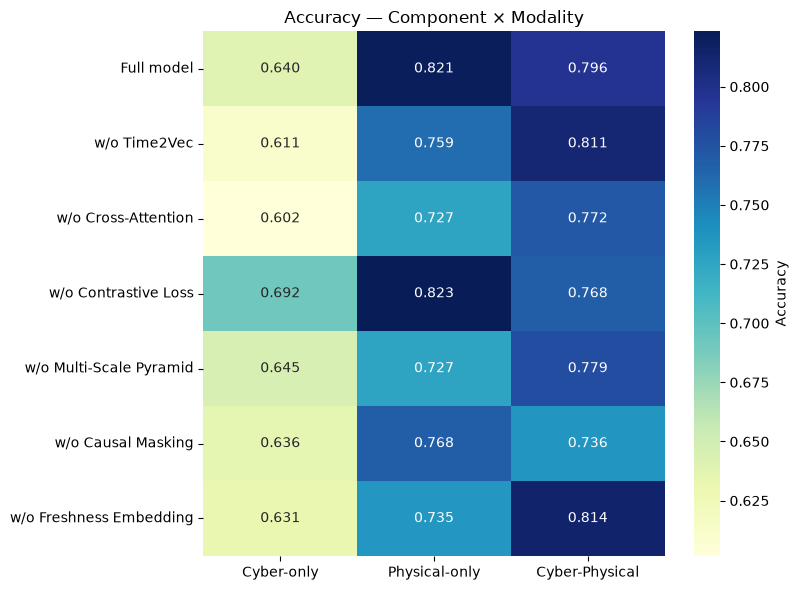

In [11]:
pivot_acc = pd.DataFrame({
    m: [ablation_results[f"{c}__{m}"]["accuracy"] for c in COMPONENT_NAMES]
    for m in MODALITIES
}, index=[component_display[c] for c in COMPONENT_NAMES])
pivot_acc.columns = [modality_display[m] for m in MODALITIES]
pivot_acc = pivot_acc.round(4)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Accuracy"})
ax.set_title("Accuracy — Component × Modality")
plt.tight_layout()
plt.savefig("figures/component_modality_ablation/pivoted_view_component_modality.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-Class F1 Heatmap (21 combinations)

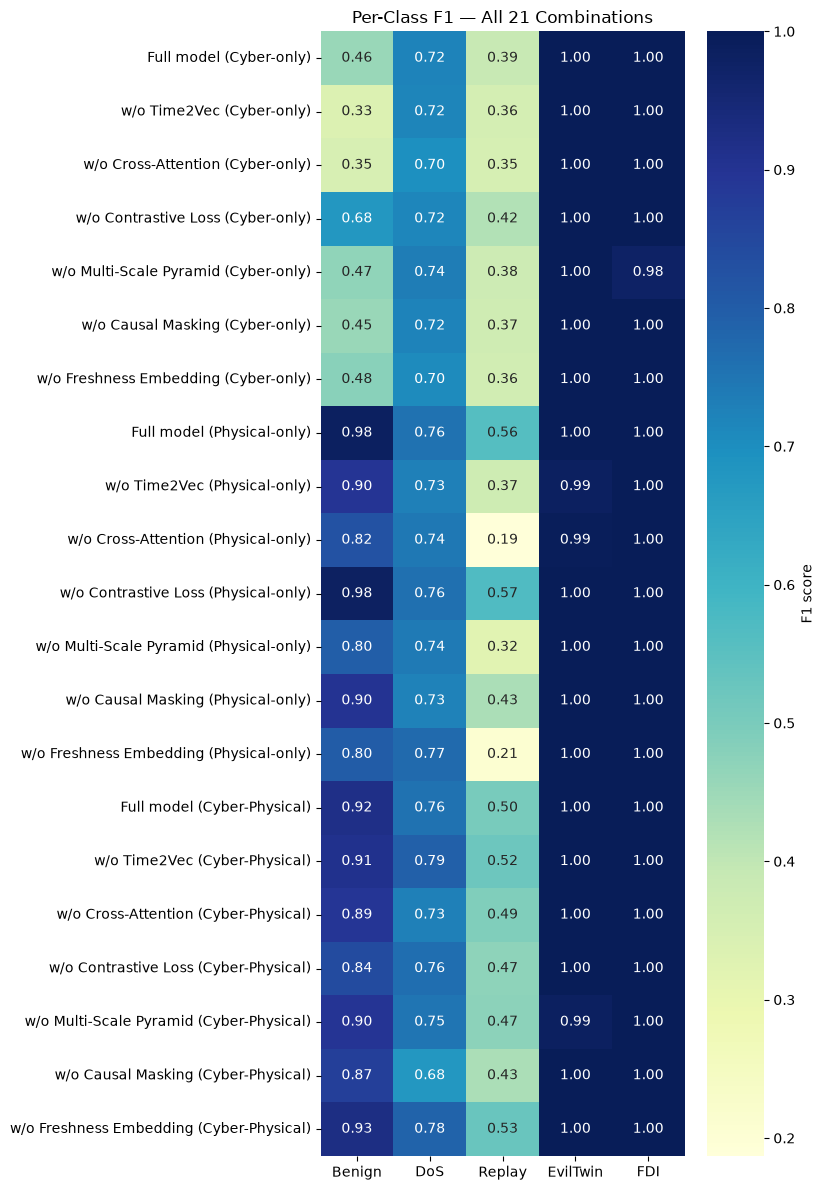

In [12]:
per_class_df = pd.DataFrame({display_name(key): ablation_results[key]["per_class_f1"] for key in ALL_KEYS}).T
per_class_df = per_class_df[CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(per_class_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "F1 score"})
ax.set_title("Per-Class F1 — All 21 Combinations")
plt.tight_layout()
plt.savefig("figures/component_modality_ablation/per_class_f1_heatmap_21_combinations.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Impact Ranking (within each modality)

Ranks each ablated component by how much removing it hurts F1 relative to the
**full model under the same modality** — the "full" baseline differs by modality
(cyber-only full vs. physical-only full vs. cyber-physical full), so the ranking is
computed separately per modality rather than against one global baseline.

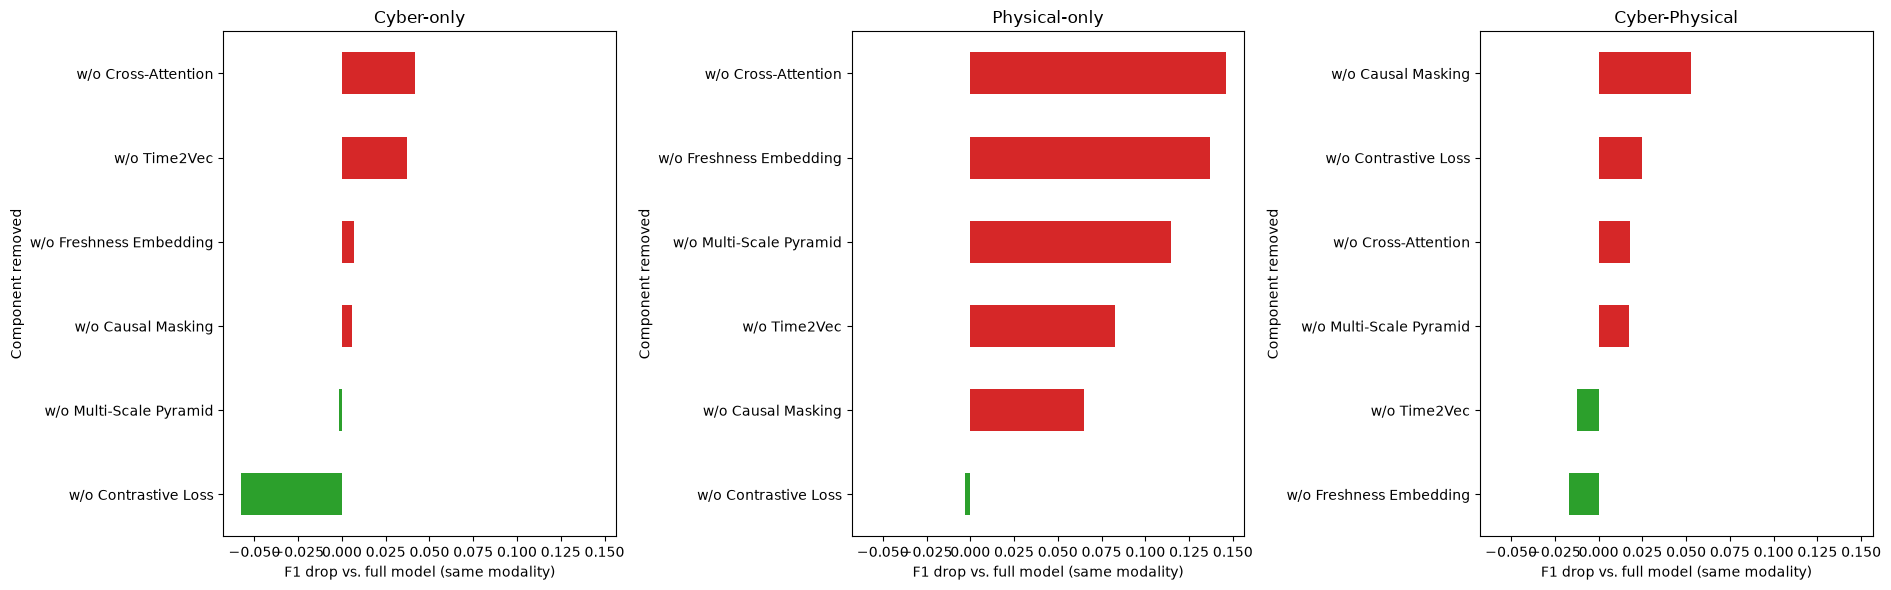

F1 drop
Modality Component removed               
cyber    w/o Cross-Attention       0.0420
         w/o Time2Vec              0.0369
         w/o Freshness Embedding   0.0069
         w/o Causal Masking        0.0057
         w/o Multi-Scale Pyramid  -0.0018
         w/o Contrastive Loss     -0.0576
physical w/o Cross-Attention       0.1463
         w/o Freshness Embedding   0.1369
         w/o Multi-Scale Pyramid   0.1147
         w/o Time2Vec              0.0827
         w/o Causal Masking        0.0649
         w/o Contrastive Loss     -0.0028
both     w/o Causal Masking        0.0530
         w/o Contrastive Loss      0.0248
         w/o Cross-Attention       0.0178
         w/o Multi-Scale Pyramid   0.0175
         w/o Time2Vec             -0.0122
         w/o Freshness Embedding  -0.0168

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharex=True)

impact_dfs = {}
for ax, modality in zip(axes, MODALITIES):
    full_f1 = ablation_results[f"full__{modality}"]["f1_weighted"]
    rows = []
    for c in COMPONENT_NAMES:
        if c == "full":
            continue
        delta = full_f1 - ablation_results[f"{c}__{modality}"]["f1_weighted"]
        rows.append({"Component removed": component_display[c], "F1 drop": round(delta, 4)})
    df_ = pd.DataFrame(rows).sort_values("F1 drop", ascending=False).set_index("Component removed")
    impact_dfs[modality] = df_

    colors = ["#d62728" if v > 0 else "#2ca02c" for v in df_["F1 drop"]]
    df_["F1 drop"].plot(kind="barh", ax=ax, color=colors)
    ax.set_title(modality_display[modality])
    ax.set_xlabel("F1 drop vs. full model (same modality)")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figures/component_modality_ablation/impact_ranking_within_each_modality.png", dpi=150, bbox_inches="tight")
plt.show()

impact_df = pd.concat(impact_dfs, names=["Modality", "Component removed"])
impact_df

## 12. Combined ROC Curves

**Per-modality figures**: for each modality, one figure overlaying all 7 component
variants (macro-average one-vs-rest ROC) — shows which components matter most
*within* that modality.

**Headline figure**: the `full` component variant across all 3 modalities — the
direct cyber/physical/cyber-physical comparison, now with ROC curves included.

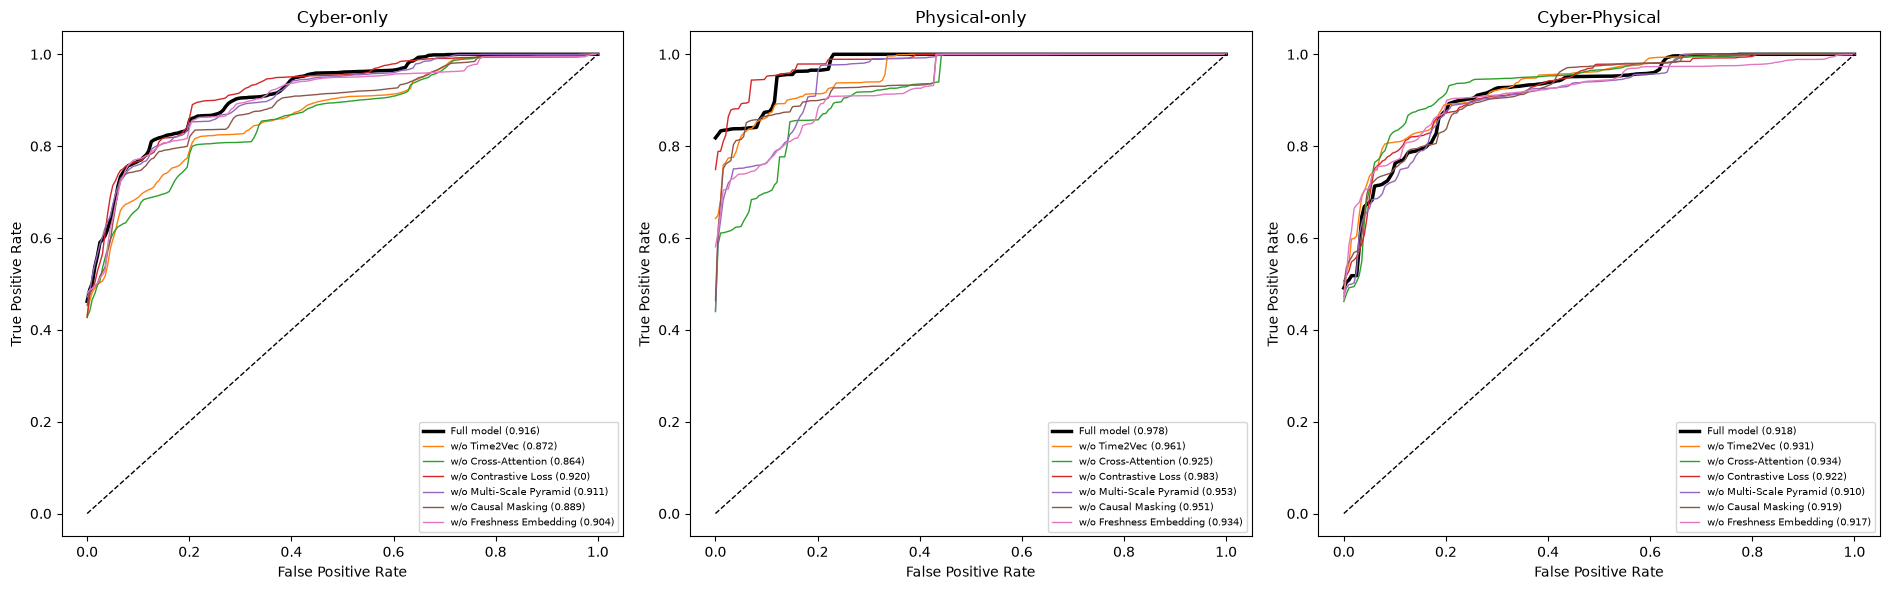

In [14]:
def macro_ovr_roc(y_true, y_pred_proba, n_classes=NUM_CLASSES):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    fpr_grid = np.linspace(0, 1, 200)
    tprs = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        tprs.append(np.interp(fpr_grid, fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    return fpr_grid, mean_tpr, auc(fpr_grid, mean_tpr)


fig, axes = plt.subplots(1, 3, figsize=(19, 6))
palette = cm.tab10.colors[:len(COMPONENT_NAMES)]

for ax, modality in zip(axes, MODALITIES):
    for i, c in enumerate(COMPONENT_NAMES):
        key = f"{c}__{modality}"
        fpr_grid, mean_tpr, roc_auc_val = macro_ovr_roc(y_test, ablation_probas[key])
        is_full = c == "full"
        ax.plot(fpr_grid, mean_tpr, label=f"{component_display[c]} ({roc_auc_val:.3f})",
                color="black" if is_full else palette[i], linewidth=2.5 if is_full else 1)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(modality_display[modality])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig("figures/component_modality_ablation/combined_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

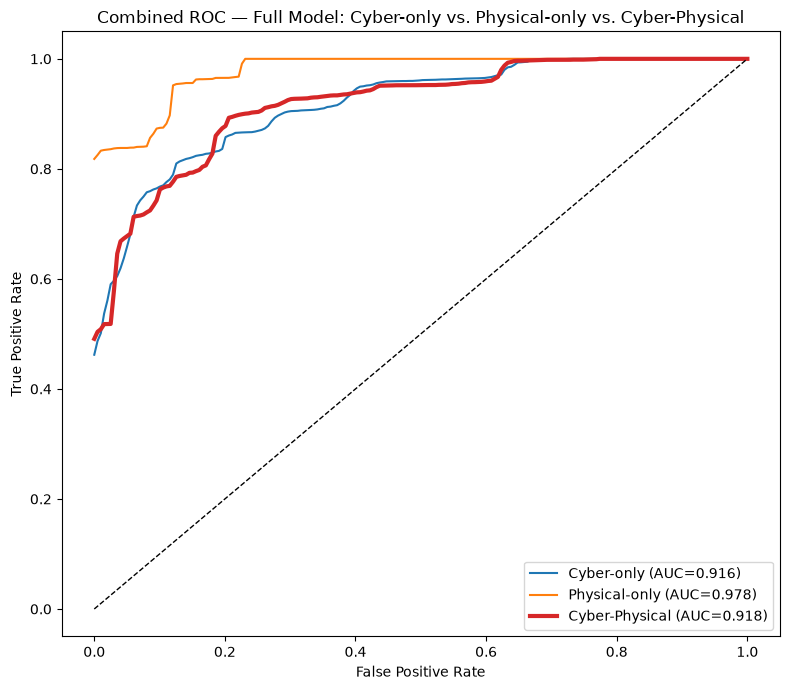

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {"cyber": "#1f77b4", "physical": "#ff7f0e", "both": "#d62728"}

for modality in MODALITIES:
    key = f"full__{modality}"
    fpr_grid, mean_tpr, roc_auc_val = macro_ovr_roc(y_test, ablation_probas[key])
    lw = 3 if modality == "both" else 1.5
    ax.plot(fpr_grid, mean_tpr, label=f"{modality_display[modality]} (AUC={roc_auc_val:.3f})",
            color=colors[modality], linewidth=lw)

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Combined ROC — Full Model: Cyber-only vs. Physical-only vs. Cyber-Physical")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/component_modality_ablation/combined_roc_curves_2.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion Matrices — 3×7 Grid (Modality × Component)

Rows = modality (cyber-only / physical-only / cyber-physical), columns = component
variant — directly laying out the requested cyber/physical/cyber-physical
comparison alongside every component ablation.

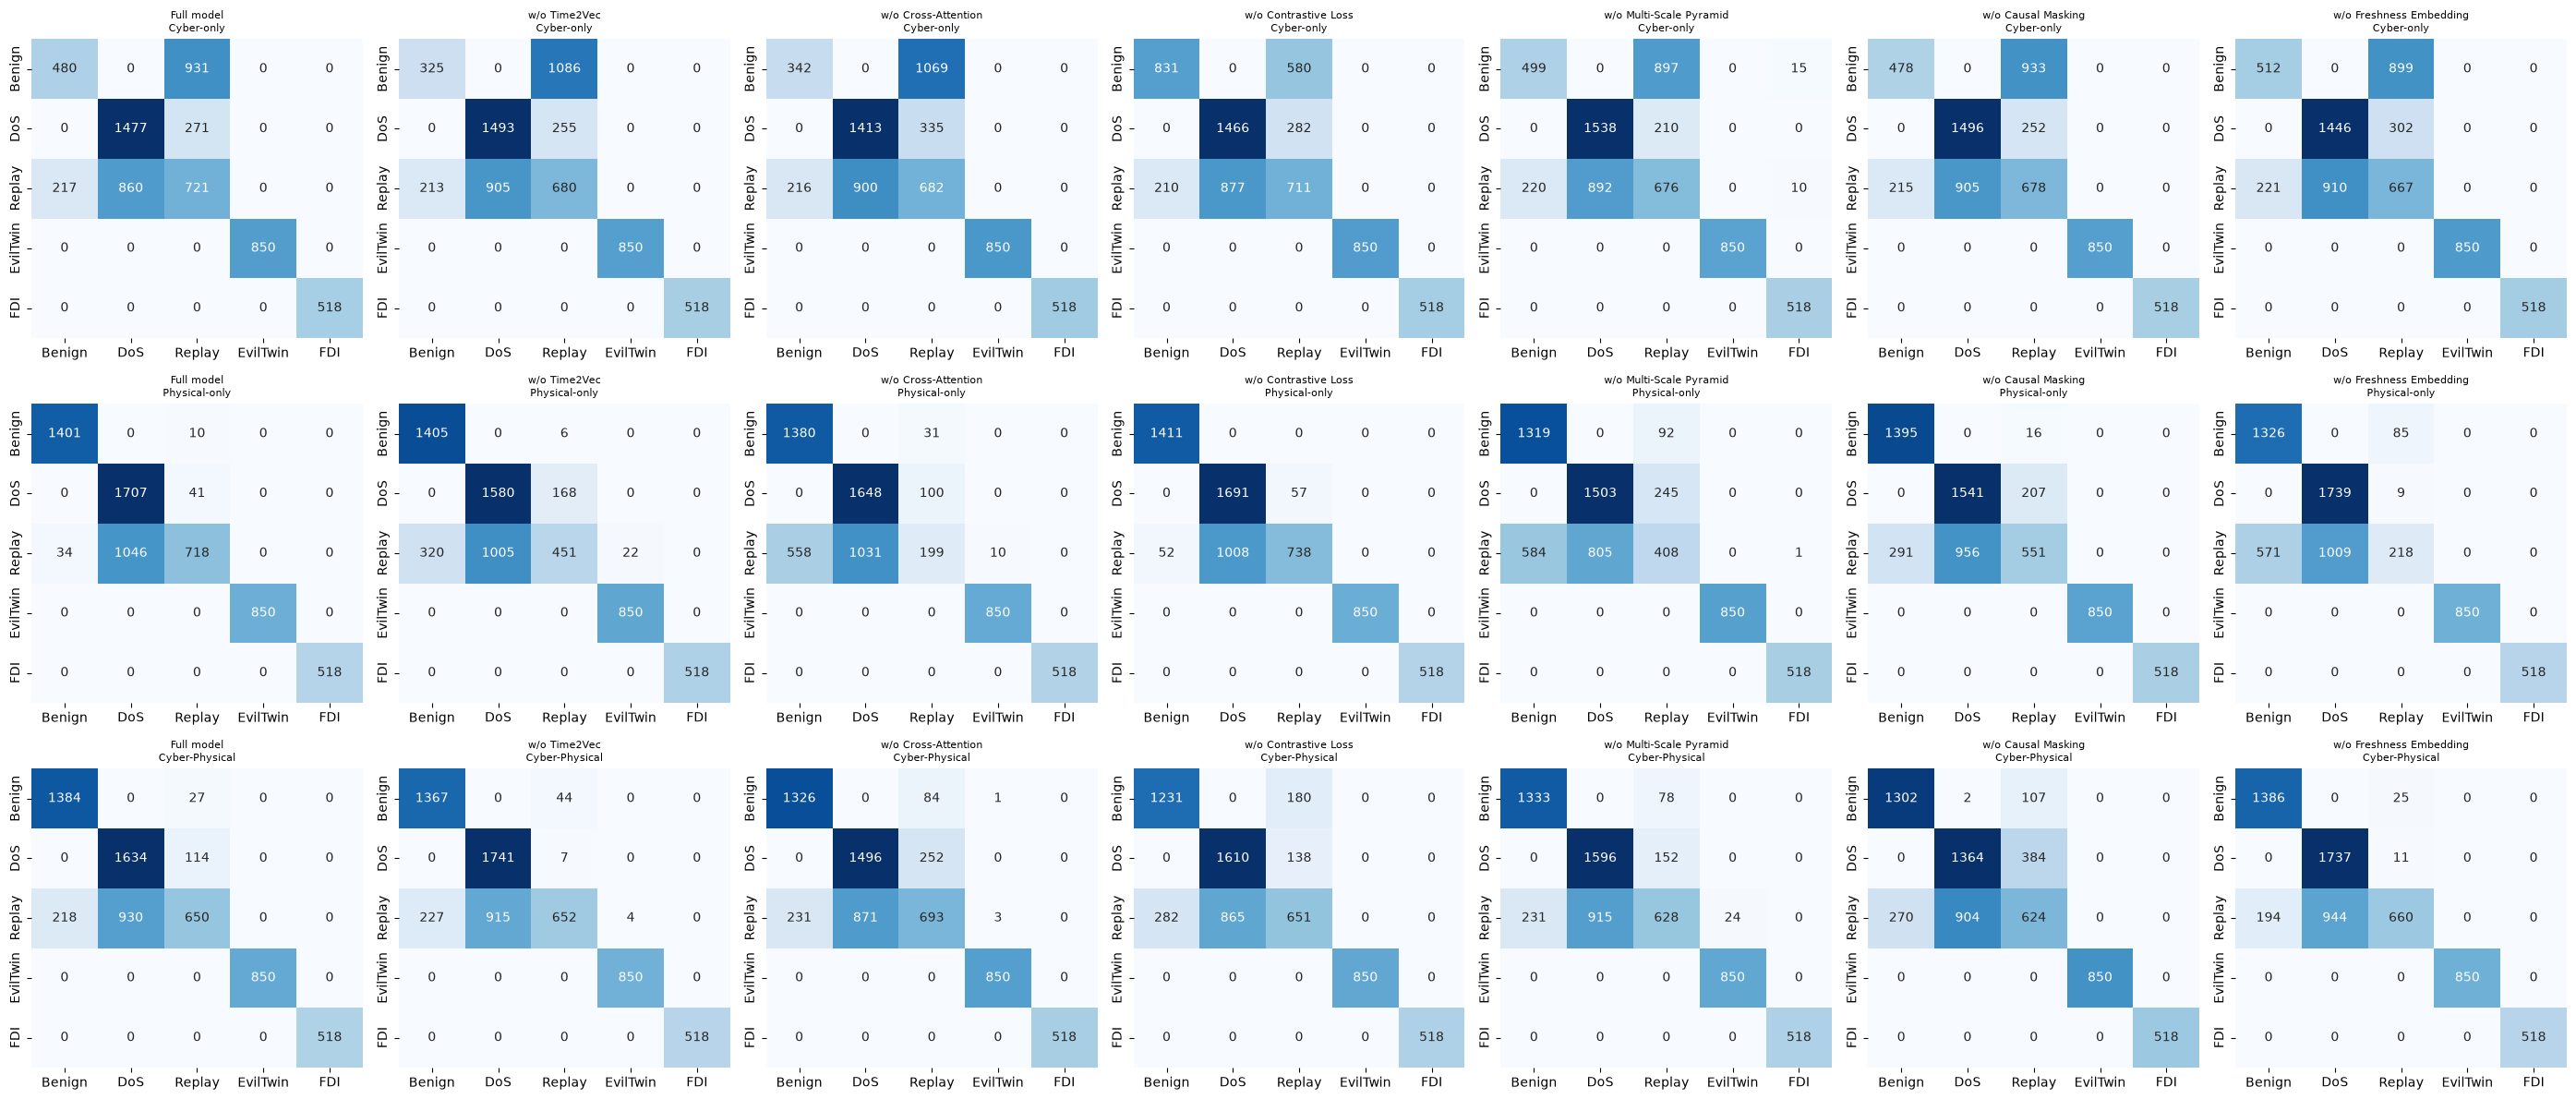

In [16]:
fig, axes = plt.subplots(3, 7, figsize=(28, 12))

for row, modality in enumerate(MODALITIES):
    for col, c in enumerate(COMPONENT_NAMES):
        ax = axes[row, col]
        key = f"{c}__{modality}"
        sns.heatmap(ablation_confusions[key], annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
        ax.set_title(f"{component_display[c]}\n{modality_display[modality]}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig("figures/component_modality_ablation/confusion_matrices_3_7_grid_modality_component.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Training Curves — Grouped by Modality

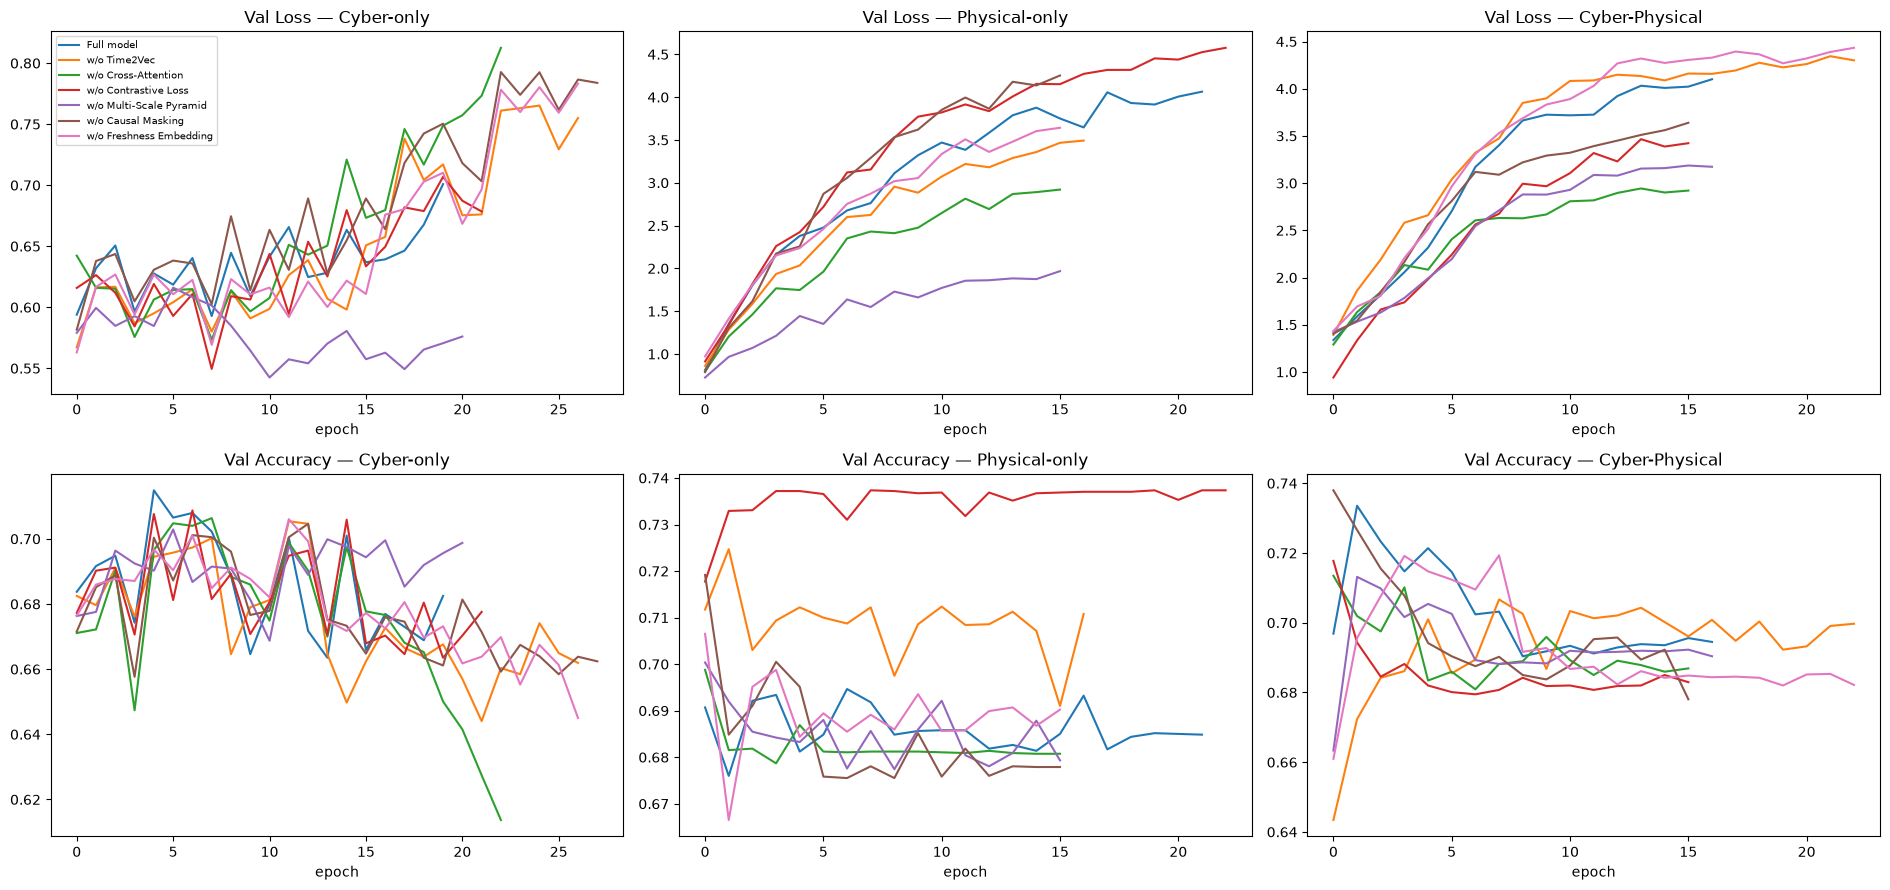

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(19, 9))

for col, modality in enumerate(MODALITIES):
    for c in COMPONENT_NAMES:
        key = f"{c}__{modality}"
        axes[0, col].plot(ablation_histories[key]["val_loss"], label=component_display[c])
        axes[1, col].plot(ablation_histories[key]["val_accuracy"], label=component_display[c])
    axes[0, col].set_title(f"Val Loss — {modality_display[modality]}")
    axes[1, col].set_title(f"Val Accuracy — {modality_display[modality]}")
    axes[0, col].set_xlabel("epoch")
    axes[1, col].set_xlabel("epoch")

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.savefig("figures/component_modality_ablation/training_curves_grouped_by_modality.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Save Ablation Results

In [18]:
os.makedirs("results", exist_ok=True)

summary_df.to_csv("results/component_modality_ablation_summary.csv")
pivot_f1.to_csv("results/component_modality_ablation_pivot_f1.csv")
per_class_df.to_csv("results/component_modality_ablation_per_class_f1.csv")
impact_df.to_csv("results/component_modality_ablation_impact_ranking.csv")

with open("results/component_modality_ablation_full.json", "w") as f:
    json.dump({
        key: {**ablation_results[key], "confusion_matrix": ablation_confusions[key].tolist()}
        for key in ALL_KEYS
    }, f, indent=2)

print("Saved:")
print("  results/component_modality_ablation_summary.csv        (21 combinations)")
print("  results/component_modality_ablation_pivot_f1.csv        (component x modality)")
print("  results/component_modality_ablation_per_class_f1.csv")
print("  results/component_modality_ablation_impact_ranking.csv  (per modality)")
print("  results/component_modality_ablation_full.json           (includes confusion matrices)")
print("  mstc_ids_<component>__<modality>_best.keras  (21 checkpoints)")

Saved:
  results/component_modality_ablation_summary.csv        (21 combinations)
  results/component_modality_ablation_pivot_f1.csv        (component x modality)
  results/component_modality_ablation_per_class_f1.csv
  results/component_modality_ablation_impact_ranking.csv  (per modality)
  results/component_modality_ablation_full.json           (includes confusion matrices)
  mstc_ids_<component>__<modality>_best.keras  (21 checkpoints)
